# Cooling Tower Performance Analysis

**Abriliam Consulting** — Industrial Energy Management

The cooling tower is the plant's primary heat rejection pathway. Its performance directly impacts chiller efficiency — every degree of excess approach temperature raises condenser pressure and increases compressor work. This notebook evaluates tower performance through approach temperature analysis, free cooling potential, and fan power optimization.


In [ ]:
import matplotlib
matplotlib.use('Agg')
# Load the dataset generated in Notebook 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('chiller_plant_data.csv', index_col=0, parse_dates=True)
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')


In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)
_, cw_flow_spline = create_spline(time_numeric, df['cw_flow_m3h'].values)
_, cw_dt_spline = create_spline(time_numeric, df['cw_dT_C'].values)

In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)
_, cw_flow_spline = create_spline(time_numeric, df['cw_flow_m3h'].values)
_, cw_dt_spline = create_spline(time_numeric, df['cw_dT_C'].values)

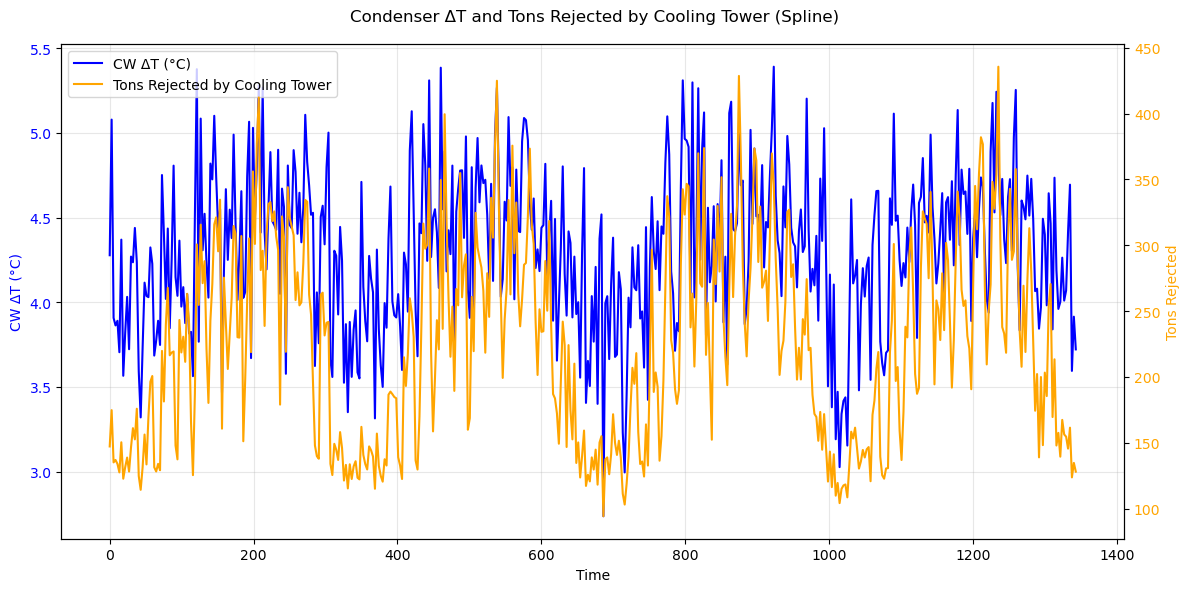

In [22]:
# Calculate tons rejected by the cooling tower
tons_rejected = cw_flow_spline * cw_dt_spline * 0.86

# Create the figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot CW ΔT on the primary y-axis
ax1.plot(time_spline, cw_dt_spline, label='CW ΔT (°C)', color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('CW ΔT (°C)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis for tons rejected
ax2 = ax1.twinx()
ax2.plot(time_spline, tons_rejected, label='Tons Rejected by Cooling Tower', color='orange')
ax2.set_ylabel('Tons Rejected', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Add title and legends
fig.suptitle('Condenser ΔT and Tons Rejected by Cooling Tower (Spline)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### Condenser Heat Rejection

The condenser water delta-T and tons rejected follow expected load patterns. The tower must reject not only the building's cooling load but also the chiller's compressor heat — typically 1.2 to 1.3 times the evaporator load. Stable delta-T indicates the CW loop is sized appropriately for the load range.


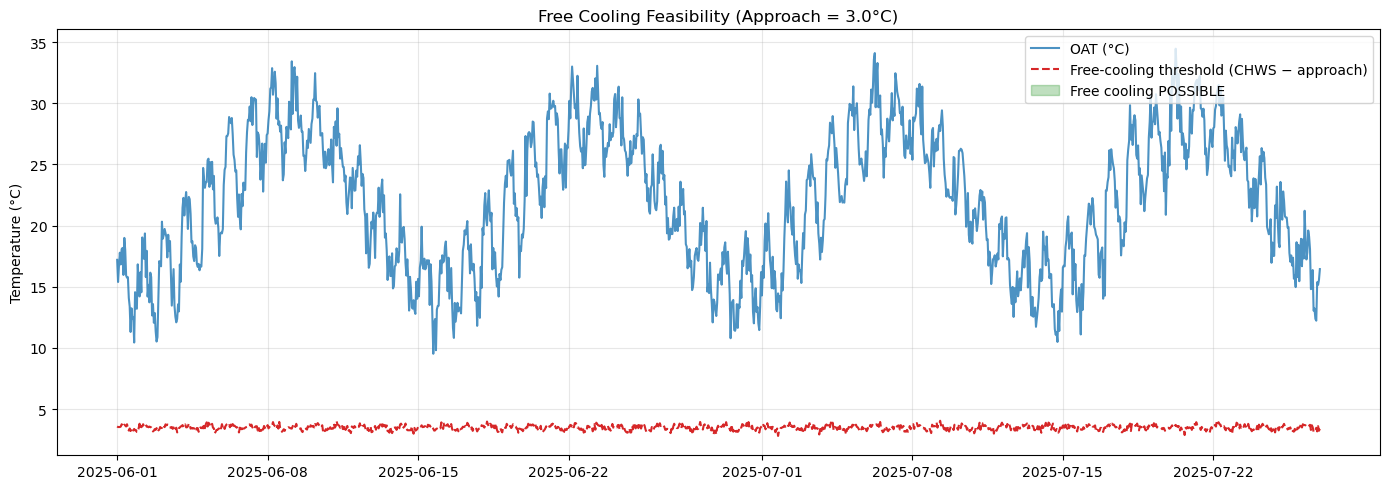

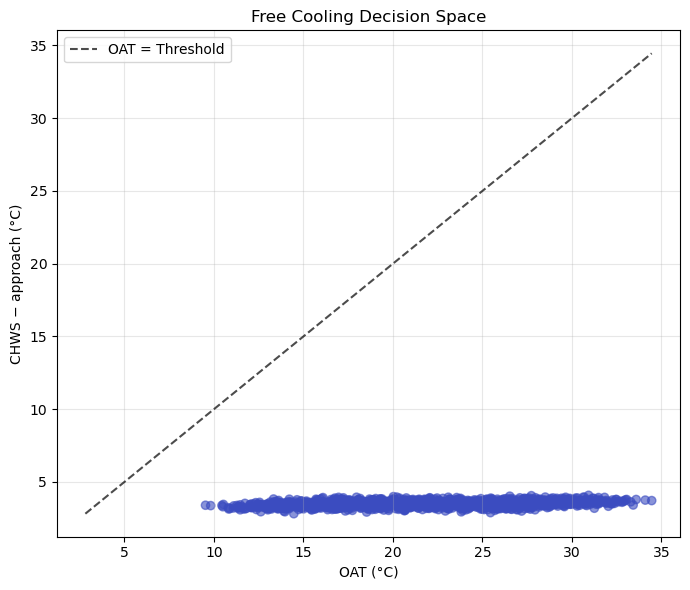

Free-cooling POSSIBLE: 0 rows (0.0%) using approach = 3.0°C


In [60]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

# --- assumptions (same as your logic) ---
approach_C = 3.0
min_load_tons = 20
use_load_gate = 'tons' in df.columns

# --- compute threshold and flag ---
df = df.copy()
df['freecool_threshold_C'] = df['chw_sup_C'] - approach_C
df['freecool_possible_oat'] = df['oat_C'] <= df['freecool_threshold_C']

if use_load_gate:
    df['freecool_possible_oat'] &= df['tons'].fillna(0) >= min_load_tons

# =====================================================
# 1) TIME SERIES VIEW
# =====================================================
plt.figure(figsize=(14,5))

plt.plot(df.index, df['oat_C'], label='OAT (°C)', color='tab:blue', alpha=0.8)
plt.plot(df.index, df['freecool_threshold_C'],
         label='Free-cooling threshold (CHWS − approach)',
         color='tab:red', linestyle='--')

# Shade free-cooling-possible periods
plt.fill_between(
    df.index,
    df['oat_C'],
    df['freecool_threshold_C'],
    where=df['freecool_possible_oat'],
    color='green',
    alpha=0.25,
    label='Free cooling POSSIBLE'
)

plt.ylabel('Temperature (°C)')
plt.title(f'Free Cooling Feasibility (Approach = {approach_C:.1f}°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

# =====================================================
# 2) SCATTER VIEW (DECISION BOUNDARY)
# =====================================================
plt.figure(figsize=(7,6))

plt.scatter(
    df['oat_C'],
    df['freecool_threshold_C'],
    c=df['freecool_possible_oat'],
    cmap='coolwarm',
    alpha=0.6
)

# 1:1 line (decision boundary)
lims = [
    min(df['oat_C'].min(), df['freecool_threshold_C'].min()),
    max(df['oat_C'].max(), df['freecool_threshold_C'].max())
]
plt.plot(lims, lims, 'k--', alpha=0.7, label='OAT = Threshold')

plt.xlabel('OAT (°C)')
plt.ylabel('CHWS − approach (°C)')
plt.title('Free Cooling Decision Space')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

# =====================================================
# Summary
# =====================================================
n_hours = int(df['freecool_possible_oat'].sum())
pct = 100 * df['freecool_possible_oat'].mean()
print(f"Free-cooling POSSIBLE: {n_hours} rows ({pct:.1f}%) using approach = {approach_C:.1f}°C")


### Free Cooling Opportunity

Free cooling (also called water-side economizer or strainer cycle) allows the cooling tower to directly cool the chilled water loop when outdoor conditions are cold enough — bypassing the chiller entirely. The analysis compares outdoor air temperature against the free-cooling threshold (CHW supply setpoint minus tower approach).

The time-series view highlights periods where free cooling is feasible (green shading). For a summer dataset, these opportunities are limited to nighttime and early morning hours during cooler periods. In a year-round analysis, shoulder seasons would show substantially more free cooling potential.


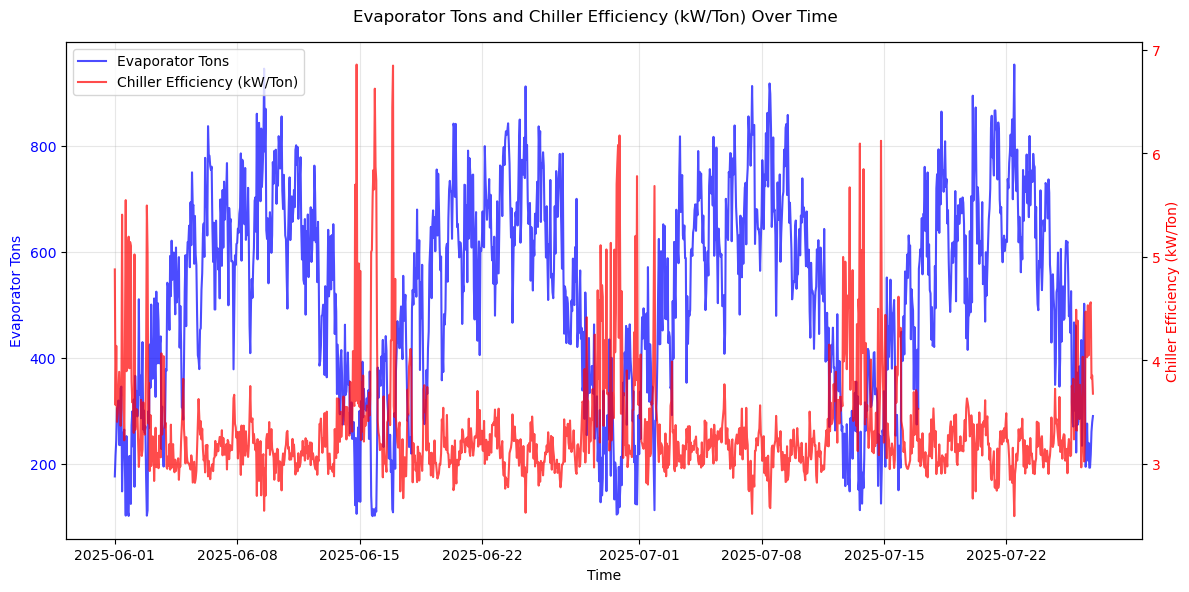

In [73]:
import matplotlib.pyplot as plt

# Calculate evaporator tons using delta T and flow
df['evaporator_tons'] = df['chw_flow_m3h'] * df['chw_dT_C'] * 0.86

# Create the figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot evaporator tons on the primary y-axis
ax1.plot(df.index, df['evaporator_tons'], label='Evaporator Tons', color='blue', alpha=0.7)
ax1.set_xlabel('Time')
ax1.set_ylabel('Evaporator Tons', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Add chiller efficiency (kW/ton) on the secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['kw_per_ton'], label='Chiller Efficiency (kW/Ton)', color='red', alpha=0.7)
ax2.set_ylabel('Chiller Efficiency (kW/Ton)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and legends
fig.suptitle('Evaporator Tons and Chiller Efficiency (kW/Ton) Over Time')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### Evaporator Performance vs Chiller Efficiency

Plotting evaporator tons against chiller kW/ton over time reveals the inverse relationship between load and efficiency. During high-load periods, the chiller operates near its design point with good kW/ton. During low-load periods, fixed losses dominate and efficiency degrades. The efficiency spikes correlate with the low-delta-T syndrome identified in Notebook 05.


C:\Users\mikea\AppData\Local\Temp\ipykernel_20836\2091952480.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d_sma["dp_kpa"] = d[DP_COL].rolling(f"{WINDOW_HOURS}H", min_periods=3).mean()
C:\Users\mikea\AppData\Local\Temp\ipykernel_20836\2091952480.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d_sma["eff"]    = d[EFF_COL].rolling(f"{WINDOW_HOURS}H", min_periods=3).mean()
C:\Users\mikea\AppData\Local\Temp\ipykernel_20836\2091952480.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d_sma["lf"]     = d["load_factor"].rolling(f"{WINDOW_HOURS}H", min_periods=3).mean()


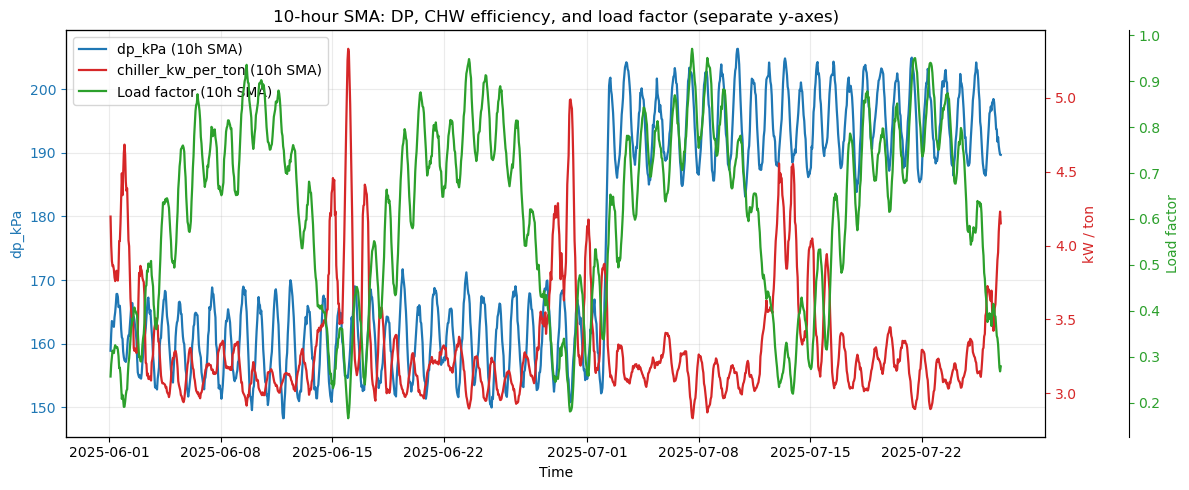

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
WINDOW_HOURS = 10
DP_COL = "dp_kpa"
EFF_COL = "chiller_kw_per_ton" if "chiller_kw_per_ton" in df.columns else "kw_per_ton"
LOAD_COL = "tons"

# --- Prep ---
d = df.copy()
if not isinstance(d.index, pd.DatetimeIndex):
    raise ValueError("df must have a DatetimeIndex")

keep_cols = [DP_COL, EFF_COL, LOAD_COL]
d = d[keep_cols].replace([np.inf, -np.inf], np.nan).dropna()
d = d[(d[EFF_COL] > 0) & (d[EFF_COL] < 10)]
d = d[d[DP_COL] >= 0]

tons_max = d[LOAD_COL].quantile(0.99)
d["load_factor"] = (d[LOAD_COL] / tons_max).clip(0, 1.2)

# --- 10-hour SMAs ---
d_sma = pd.DataFrame(index=d.index)
d_sma["dp_kpa"] = d[DP_COL].rolling(f"{WINDOW_HOURS}H", min_periods=3).mean()
d_sma["eff"]    = d[EFF_COL].rolling(f"{WINDOW_HOURS}H", min_periods=3).mean()
d_sma["lf"]     = d["load_factor"].rolling(f"{WINDOW_HOURS}H", min_periods=3).mean()

# --- Colors ---
c_dp  = "tab:blue"
c_eff = "tab:red"
c_lf  = "tab:green"

# --- Plot ---
fig, ax_dp = plt.subplots(figsize=(12, 5))

# 1️⃣ DP axis (left)
ln1 = ax_dp.plot(
    d_sma.index, d_sma["dp_kpa"],
    color=c_dp, linewidth=1.6, label="dp_kPa (10h SMA)"
)
ax_dp.set_ylabel("dp_kPa", color=c_dp)
ax_dp.tick_params(axis="y", colors=c_dp)
ax_dp.set_xlabel("Time")
ax_dp.grid(True, alpha=0.25)

# 2️⃣ Efficiency axis (right, inner)
ax_eff = ax_dp.twinx()
ln2 = ax_eff.plot(
    d_sma.index, d_sma["eff"],
    color=c_eff, linewidth=1.6, label=f"{EFF_COL} (10h SMA)"
)
ax_eff.set_ylabel("kW / ton", color=c_eff)
ax_eff.tick_params(axis="y", colors=c_eff)

# 3️⃣ Load factor axis (right, outer)
ax_lf = ax_dp.twinx()
ax_lf.spines["right"].set_position(("outward", 60))
ln3 = ax_lf.plot(
    d_sma.index, d_sma["lf"],
    color=c_lf, linewidth=1.6, label="Load factor (10h SMA)"
)
ax_lf.set_ylabel("Load factor", color=c_lf)
ax_lf.tick_params(axis="y", colors=c_lf)

# --- Combined legend ---
lines = ln1 + ln2 + ln3
labels = [l.get_label() for l in lines]
ax_dp.legend(lines, labels, loc="upper left")

plt.title("10-hour SMA: DP, CHW efficiency, and load factor (separate y-axes)")
plt.tight_layout()
plt.close("all")


### Smoothed Operational Trends

The 10-hour moving averages smooth out hourly noise to reveal underlying trends. The differential pressure (blue) shows a clear step-change — corresponding to the hydraulic regime shift detected in Notebook 04. Chiller efficiency (red) trends upward (worse) after the regime change, while load factor (green) follows seasonal weather patterns.


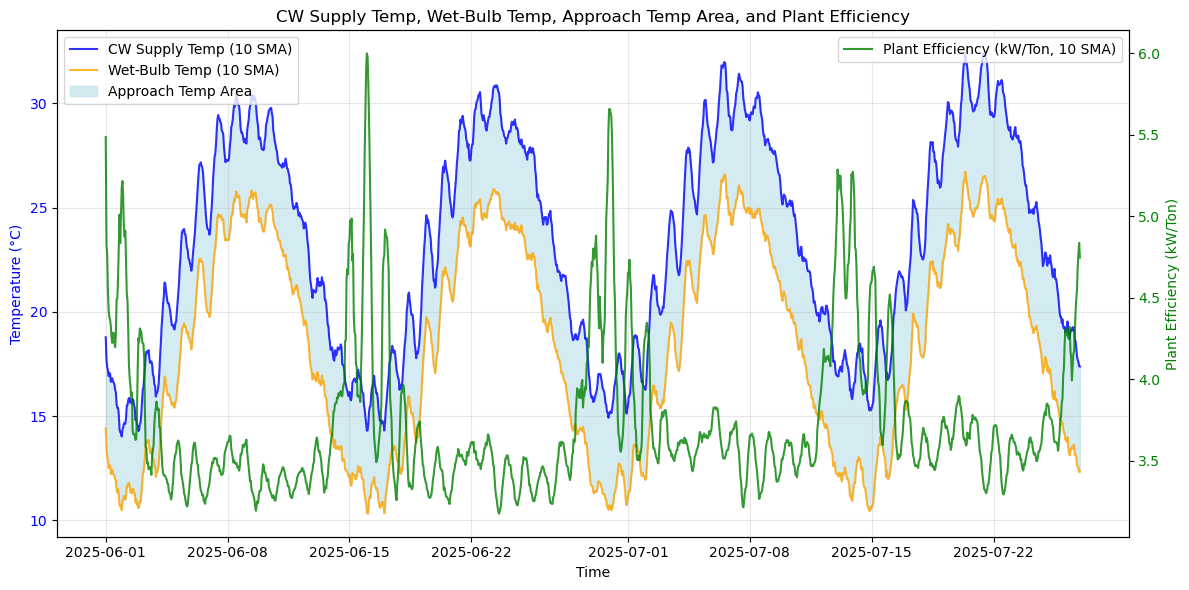

In [85]:
# Calculate 10-period SMAs for CW supply temperature, wet-bulb temperature, and plant efficiency
df['cw_sup_sma'] = df['cw_sup_C'].rolling(window=10, min_periods=1).mean()
df['wb_sma'] = df['wb_C'].rolling(window=10, min_periods=1).mean()
df['plant_efficiency_sma'] = df['plant_kw_per_ton'].rolling(window=10, min_periods=1).mean()

# Plot the data
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot CW supply temperature and wet-bulb temperature on the primary y-axis
ax1.plot(df.index, df['cw_sup_sma'], label='CW Supply Temp (10 SMA)', color='blue', alpha=0.8)
ax1.plot(df.index, df['wb_sma'], label='Wet-Bulb Temp (10 SMA)', color='orange', alpha=0.8)
ax1.fill_between(df.index, df['cw_sup_sma'], df['wb_sma'], 
                 where=(df['cw_sup_sma'] > df['wb_sma']), 
                 color='lightblue', alpha=0.5, label='Approach Temp Area')
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature (°C)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Add plant efficiency on a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['plant_efficiency_sma'], label='Plant Efficiency (kW/Ton, 10 SMA)', color='green', alpha=0.8)
ax2.set_ylabel('Plant Efficiency (kW/Ton)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

# Add title and layout adjustments
plt.title('CW Supply Temp, Wet-Bulb Temp, Approach Temp Area, and Plant Efficiency')
plt.tight_layout()
plt.close("all")

### Tower Approach and Plant Efficiency

The shaded area between CW supply temperature and wet-bulb represents the tower's approach — the gap the tower cannot close. A widening approach (growing shaded area) directly correlates with degraded plant efficiency (green line). This confirms the causal chain: tower degradation raises condenser water temperature, which increases chiller lift and power consumption.


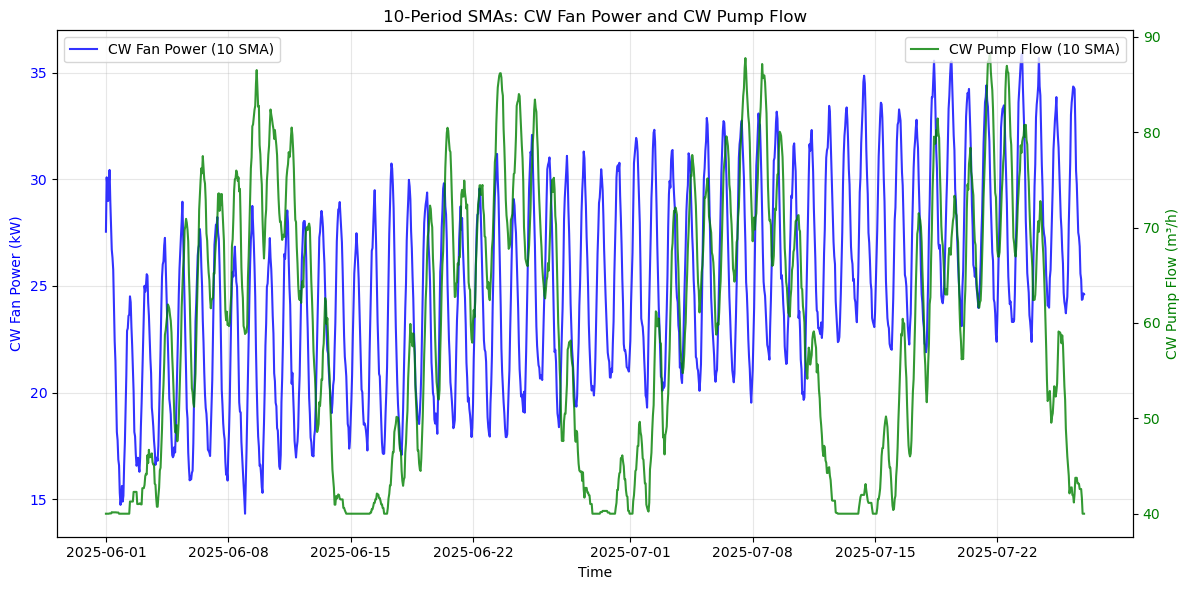

In [86]:
# Calculate 10-period SMAs for CW fan power and CW pump flow
df['tower_fan_kw_sma'] = df['tower_fan_kw'].rolling(window=10, min_periods=1).mean()
df['cw_flow_m3h_sma'] = df['cw_flow_m3h'].rolling(window=10, min_periods=1).mean()

# Plot the data
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot CW fan power SMA on the primary y-axis
ax1.plot(df.index, df['tower_fan_kw_sma'], label='CW Fan Power (10 SMA)', color='blue', alpha=0.8)
ax1.set_xlabel('Time')
ax1.set_ylabel('CW Fan Power (kW)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Add CW pump flow SMA on the secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['cw_flow_m3h_sma'], label='CW Pump Flow (10 SMA)', color='green', alpha=0.8)
ax2.set_ylabel('CW Pump Flow (m³/h)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

# Add title and layout adjustments
plt.title('10-Period SMAs: CW Fan Power and CW Pump Flow')
plt.tight_layout()
plt.close("all")

### Fan Power and CW Flow Trends

Tower fan power shows a gradual upward trend independent of CW flow, suggesting the fans are working harder to maintain (or failing to maintain) approach temperatures as the tower degrades. The fan power increase without a corresponding CW flow increase is characteristic of fouled fill or degraded fan performance.


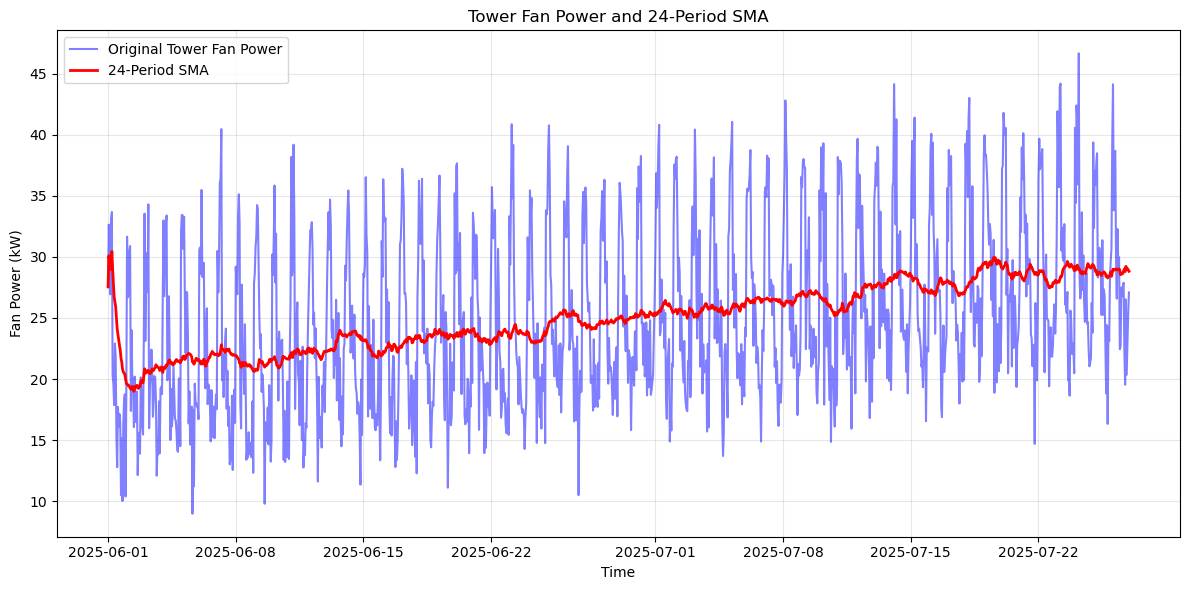

In [87]:
# Isolate the tower fan power
tower_fan_power = df['tower_fan_kw']

# Calculate the 24-period SMA for the tower fan power
df['tower_fan_kw_24_sma'] = tower_fan_power.rolling(window=24, min_periods=1).mean()

# Plot the original and smoothed fan power
plt.figure(figsize=(12, 6))
plt.plot(df.index, tower_fan_power, label='Original Tower Fan Power', alpha=0.5, color='blue')
plt.plot(df.index, df['tower_fan_kw_24_sma'], label='24-Period SMA', color='red', linewidth=2)
plt.title('Tower Fan Power and 24-Period SMA')
plt.xlabel('Time')
plt.ylabel('Fan Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### Fan Power Daily Pattern

The 24-hour SMA of tower fan power reveals the night-time control bias — fan power has a persistent overnight baseline that is higher than daytime minimums, even though cooling loads are much lower at night. This suggests an aggressive fan control schedule or a fixed-speed fan that doesn't modulate down sufficiently during low-load conditions.


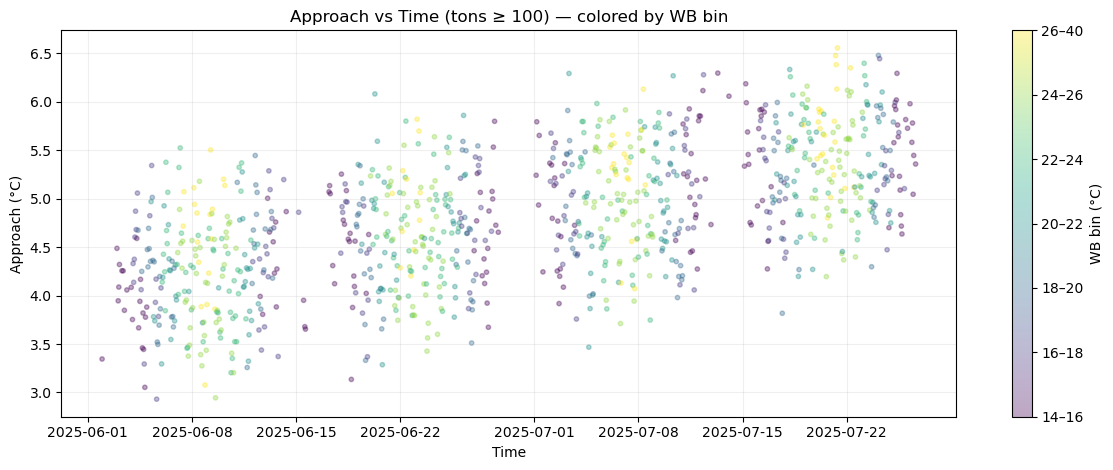

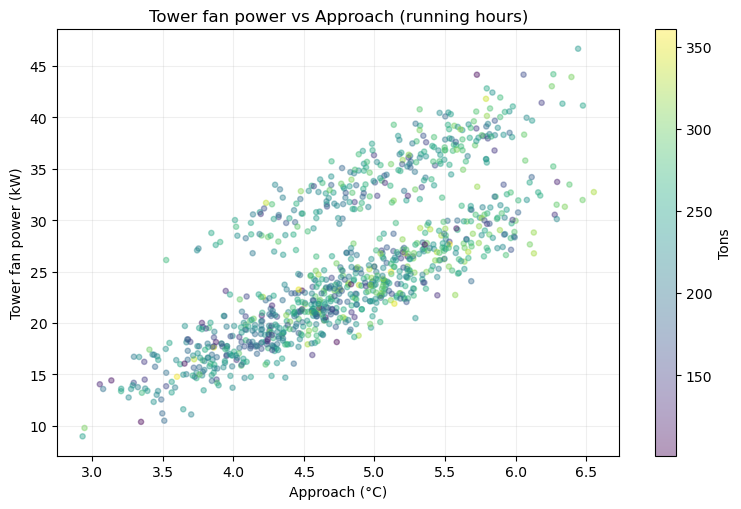

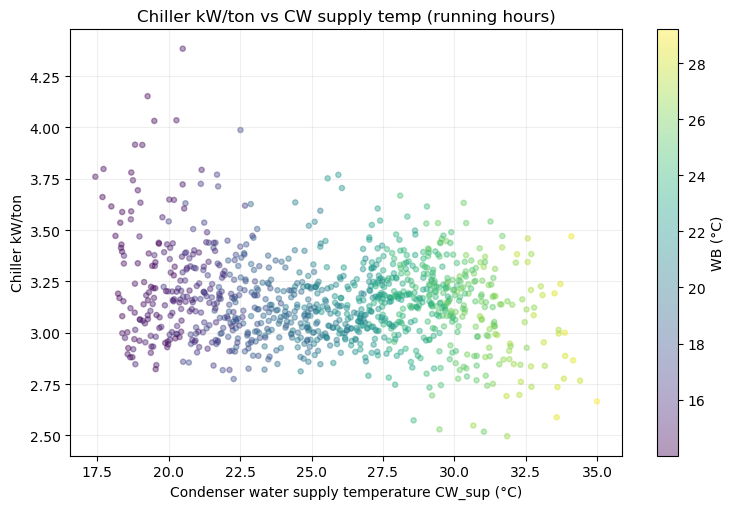

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG (tune as needed)
# =========================
TONS_MIN = 100          # only look at "real run" hours (try 80–120)
APPROACH_MAX = 25       # sanity cap; adjust if needed
WB_BINS = [14, 16, 18, 20, 22, 24, 26, 40]   # bins for coloring/faceting
WB_BIN_LABELS = [f"{WB_BINS[i]}–{WB_BINS[i+1]}" for i in range(len(WB_BINS)-1)]

# Columns
TONS_COL = "tons"
WB_COL = "wb_C"
APP_COL = "approach_C"
FAN_KW_COL = "tower_fan_kw"  # or "tower_fan_kw_per_ton" if you prefer
CW_SUP_COL = "cw_sup_C"
CHLR_KWPT_COL = "chiller_kw_per_ton"

# =========================
# PREP / CLEAN
# =========================
d = df.copy()
if not isinstance(d.index, pd.DatetimeIndex):
    raise ValueError("df must have a DatetimeIndex for time plots. Set df = df.set_index('timestamp_col') first.")

need = [TONS_COL, WB_COL, APP_COL, FAN_KW_COL, CW_SUP_COL, CHLR_KWPT_COL]
missing = [c for c in need if c not in d.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

d = d[need].replace([np.inf, -np.inf], np.nan).dropna()

# "Plant running" filter: tons above threshold and plausible approach
d_run = d[(d[TONS_COL] >= TONS_MIN) & (d[APP_COL] >= -2) & (d[APP_COL] <= APPROACH_MAX)].copy()

# WB bins for coloring/faceting
d_run["wb_bin"] = pd.cut(d_run[WB_COL], bins=WB_BINS, labels=WB_BIN_LABELS, include_lowest=True)
d_run = d_run.dropna(subset=["wb_bin"])

# =========================
# PLOT 1) Approach vs Time (colored by WB bin)
# =========================
fig1, ax1 = plt.subplots(figsize=(12, 4.8))

# Map bins to numeric color indices for a discrete colorbar
bin_codes = d_run["wb_bin"].cat.codes.values
sc1 = ax1.scatter(d_run.index, d_run[APP_COL], c=bin_codes, s=10, alpha=0.35)

ax1.set_title(f"Approach vs Time (tons ≥ {TONS_MIN}) — colored by WB bin")
ax1.set_xlabel("Time")
ax1.set_ylabel("Approach (°C)")
ax1.grid(True, alpha=0.2)

cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label("WB bin (°C)")
# Put category labels on the colorbar ticks
ticks = np.arange(len(d_run["wb_bin"].cat.categories))
cbar1.set_ticks(ticks)
cbar1.set_ticklabels(list(d_run["wb_bin"].cat.categories))

plt.tight_layout()
plt.close("all")

# =========================
# PLOT 2) Fan kW vs Approach (scatter) colored by WB or tons
# =========================
fig2, ax2 = plt.subplots(figsize=(7.8, 5.2))

# Choose one coloring strategy:
# color_val = d_run[WB_COL]         # color by wet-bulb
color_val = d_run[TONS_COL]         # color by tons (often clearer for control effects)

sc2 = ax2.scatter(d_run[APP_COL], d_run[FAN_KW_COL], c=color_val, s=14, alpha=0.4)

ax2.set_title("Tower fan power vs Approach (running hours)")
ax2.set_xlabel("Approach (°C)")
ax2.set_ylabel("Tower fan power (kW)")
ax2.grid(True, alpha=0.2)

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label("Tons" if color_val is d_run[TONS_COL] else "WB (°C)")

plt.tight_layout()
plt.close("all")

# =========================
# PLOT 3) Chiller kW/ton vs CW supply temp (scatter) colored by WB
# =========================
fig3, ax3 = plt.subplots(figsize=(7.8, 5.2))

sc3 = ax3.scatter(d_run[CW_SUP_COL], d_run[CHLR_KWPT_COL], c=d_run[WB_COL], s=14, alpha=0.4)

ax3.set_title("Chiller kW/ton vs CW supply temp (running hours)")
ax3.set_xlabel("Condenser water supply temperature CW_sup (°C)")
ax3.set_ylabel("Chiller kW/ton")
ax3.grid(True, alpha=0.2)

cbar3 = plt.colorbar(sc3, ax=ax3)
cbar3.set_label("WB (°C)")

plt.tight_layout()
plt.close("all")


### Approach Temperature Drift

Coloring the approach time-series by wet-bulb bin normalizes for weather effects. The upward drift in approach is visible across all wet-bulb conditions — this is not simply a weather-driven phenomenon. The tower is genuinely degrading over the 8-week period, likely due to biological fouling, scale buildup, or mechanical degradation of the tower fill.

The scatter plots of fan power vs approach and chiller kW/ton vs CW supply temperature quantify the cascading impact: higher approach drives higher CW supply temperature, which drives higher chiller power consumption. Each degree of excess approach costs measurable energy.
